In [26]:
import numpy as np
import matplotlib.pyplot as plt
import time
from qiskit import QuantumCircuit
from qiskit.compiler import transpile
from log_mcx_x_cx_ccx import mcx_log_gate, access_mcx_log_depth, access_mcx_size
from exact_one_x_cx_ccx import exact_one_gate, access_exact_one_depth, access_exact_one_size
from spue_circuit import build_prepare_select_prepare_dag


***Depth and Size scaling of MCX***

In [27]:
log_n_min=1
log_n_max=5
steps=25

raw_ns = np.logspace(log_n_min, log_n_max, steps)
ns = np.unique(np.round(raw_ns).astype(int))

depths = []
times = []

for n in ns:
    print(f"\nProcessing MCX with ncontrol = {n}")
    t0 = time.time()

    gate = mcx_log_gate(ncontrol=n, trace_depth_and_size=True)
    d = access_mcx_log_depth(n)

    t = time.time() - t0
    print(f"  depth = {d} (took {t:.2f}s)")

    depths.append(d)
    times.append(t)

depths = np.array(depths, dtype=float)
times = np.array(times)


Processing MCX with ncontrol = 10
  depth = 17 (took 0.01s)

Processing MCX with ncontrol = 15
  depth = 28 (took 0.01s)

Processing MCX with ncontrol = 22
  depth = 35 (took 0.01s)

Processing MCX with ncontrol = 32
  depth = 35 (took 0.01s)

Processing MCX with ncontrol = 46
  depth = 44 (took 0.01s)

Processing MCX with ncontrol = 68
  depth = 46 (took 0.01s)

Processing MCX with ncontrol = 100
  depth = 53 (took 0.01s)

Processing MCX with ncontrol = 147
  depth = 60 (took 0.01s)

Processing MCX with ncontrol = 215
  depth = 64 (took 0.01s)

Processing MCX with ncontrol = 316
  depth = 71 (took 0.02s)

Processing MCX with ncontrol = 464
  depth = 71 (took 0.02s)

Processing MCX with ncontrol = 681
  depth = 80 (took 0.03s)

Processing MCX with ncontrol = 1000
  depth = 82 (took 0.04s)

Processing MCX with ncontrol = 1468
  depth = 89 (took 0.06s)

Processing MCX with ncontrol = 2154
  depth = 96 (took 0.08s)

Processing MCX with ncontrol = 3162
  depth = 100 (took 0.12s)

Processi

In [28]:
z = np.polyfit(np.log2(ns), depths, 1)
p = np.poly1d(z)

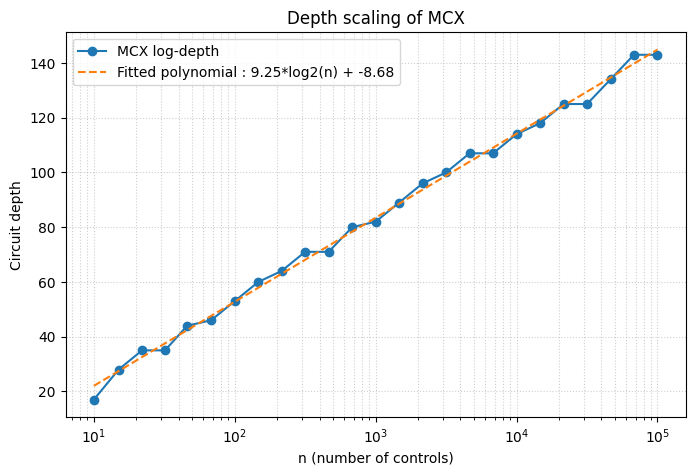

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(ns, depths, marker="o", linestyle="-", label="MCX log-depth ")
plt.plot(ns, p(np.log2(ns)), marker="", linestyle="--", label=f"Fitted polynomial : {z[0]:.2f}*log2(n) + {z[1]:.2f}")
plt.xscale("log")
plt.xlabel("n (number of controls)")
plt.ylabel("Circuit depth")
plt.title("Depth scaling of MCX")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.show()

In [30]:
n_min=1
n_max=10**5
steps=25

ns = np.unique(np.round(np.linspace(n_min, n_max, steps)).astype(int))

sizes = []
times = []

for n in ns:
    print(f"\nProcessing MCX with ncontrol = {n}")
    t0 = time.time()

    gate = mcx_log_gate(ncontrol=n, trace_depth_and_size=True)
    d = access_mcx_size(n)

    t = time.time() - t0
    print(f"  size = {d} (took {t:.2f}s)")

    sizes.append(d)
    times.append(t)

sizes = np.array(sizes, dtype=float)
times = np.array(times)


Processing MCX with ncontrol = 1
  size = 1 (took 0.00s)

Processing MCX with ncontrol = 4168
  size = 16702 (took 0.27s)

Processing MCX with ncontrol = 8334
  size = 33370 (took 0.49s)

Processing MCX with ncontrol = 12501
  size = 50038 (took 0.77s)

Processing MCX with ncontrol = 16668
  size = 66710 (took 1.06s)

Processing MCX with ncontrol = 20834
  size = 83374 (took 1.65s)

Processing MCX with ncontrol = 25001
  size = 100042 (took 1.68s)

Processing MCX with ncontrol = 29167
  size = 116706 (took 2.19s)

Processing MCX with ncontrol = 33334
  size = 133378 (took 2.66s)

Processing MCX with ncontrol = 37501
  size = 150046 (took 2.39s)

Processing MCX with ncontrol = 41667
  size = 166710 (took 2.95s)

Processing MCX with ncontrol = 45834
  size = 183378 (took 3.08s)

Processing MCX with ncontrol = 50000
  size = 200042 (took 3.34s)

Processing MCX with ncontrol = 54167
  size = 216710 (took 3.78s)

Processing MCX with ncontrol = 58334
  size = 233378 (took 4.12s)

Processing

In [31]:
z = np.polyfit(ns, sizes, 1)
p = np.poly1d(z)

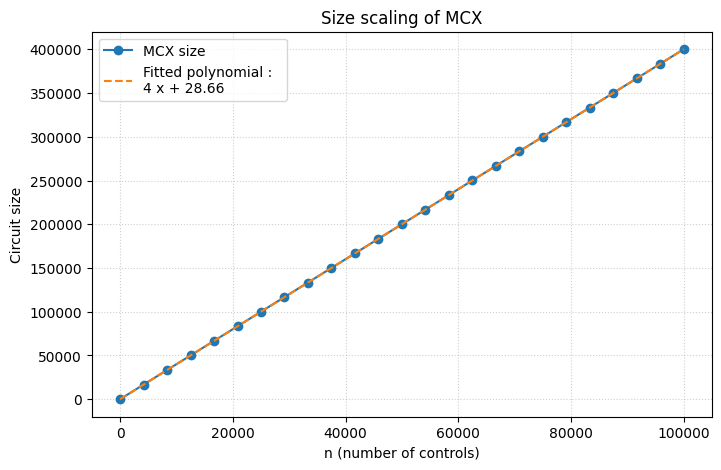

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(ns, sizes, marker="o", linestyle="-", label="MCX size ")
plt.plot(ns, p(ns), marker="", linestyle="--", label=f"Fitted polynomial : {p}")
plt.xlabel("n (number of controls)")
plt.ylabel("Circuit size")
plt.title("Size scaling of MCX")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.show()

***Depth and Size scaling of Exact One***

In [33]:
log_n_min=1
log_n_max=5
steps=25

raw_ns = np.logspace(log_n_min, log_n_max, steps)
ns = np.unique(np.round(raw_ns).astype(int))

depths = []
times = []

for n in ns:
    print(f"\nProcessing Exact One with n = {n}")
    t0 = time.time()

    gate = exact_one_gate(n, trace_depth_and_size=True)
    d = access_exact_one_depth(n)

    t = time.time() - t0
    print(f"  depth = {d} (took {t:.2f}s)")

    depths.append(d)
    times.append(t)

depths = np.array(depths, dtype=float)
times = np.array(times)


Processing Exact One with n = 10
  depth = 130 (took 0.01s)

Processing Exact One with n = 15
  depth = 182 (took 0.01s)

Processing Exact One with n = 22
  depth = 244 (took 0.02s)

Processing Exact One with n = 32
  depth = 314 (took 0.02s)

Processing Exact One with n = 46
  depth = 314 (took 0.03s)

Processing Exact One with n = 68
  depth = 392 (took 0.04s)

Processing Exact One with n = 100
  depth = 428 (took 0.04s)

Processing Exact One with n = 147
  depth = 470 (took 0.07s)

Processing Exact One with n = 215
  depth = 536 (took 0.10s)

Processing Exact One with n = 316
  depth = 560 (took 0.12s)

Processing Exact One with n = 464
  depth = 626 (took 0.20s)

Processing Exact One with n = 681
  depth = 626 (took 0.29s)

Processing Exact One with n = 1000
  depth = 704 (took 0.41s)

Processing Exact One with n = 1468
  depth = 716 (took 0.67s)

Processing Exact One with n = 2154
  depth = 782 (took 0.85s)

Processing Exact One with n = 3162
  depth = 848 (took 1.24s)

Processin

In [34]:
z = np.polyfit(np.log2(ns), depths, 1)
p = np.poly1d(z)

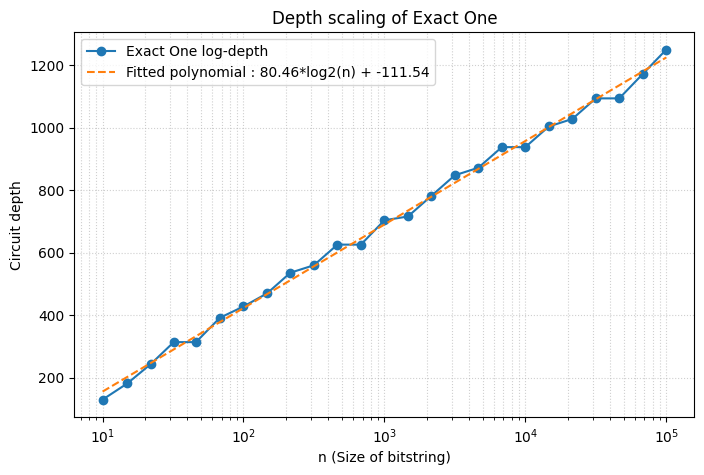

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(ns, depths, marker="o", linestyle="-", label="Exact One log-depth ")
plt.plot(ns, p(np.log2(ns)), marker="", linestyle="--", label=f"Fitted polynomial : {z[0]:.2f}*log2(n) + {z[1]:.2f}")
plt.xscale("log")
plt.xlabel("n (Size of bitstring)")
plt.ylabel("Circuit depth")
plt.title("Depth scaling of Exact One")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.show()

In [36]:
n_min=1
n_max=10**4
steps=25

ns = np.unique(np.round(np.linspace(n_min, n_max, steps)).astype(int))

sizes = []
times = []

for n in ns:
    print(f"\nProcessing Exact One with n = {n}")
    t0 = time.time()

    gate = exact_one_gate(n, trace_depth_and_size=True)
    d = access_exact_one_size(n)

    t = time.time() - t0
    print(f"  size = {d} (took {t:.2f}s)")

    sizes.append(d)
    times.append(t)

sizes = np.array(sizes, dtype=float)
times = np.array(times)


Processing Exact One with n = 1
  size = 1 (took 0.00s)

Processing Exact One with n = 418
  size = 13961 (took 0.14s)

Processing Exact One with n = 834
  size = 27857 (took 0.23s)

Processing Exact One with n = 1251
  size = 41749 (took 0.39s)

Processing Exact One with n = 1668
  size = 55681 (took 0.47s)

Processing Exact One with n = 2084
  size = 69543 (took 0.74s)

Processing Exact One with n = 2501
  size = 83445 (took 0.88s)

Processing Exact One with n = 2917
  size = 97311 (took 1.07s)

Processing Exact One with n = 3334
  size = 111233 (took 1.21s)

Processing Exact One with n = 3751
  size = 125135 (took 1.41s)

Processing Exact One with n = 4167
  size = 138997 (took 1.52s)

Processing Exact One with n = 4584
  size = 152905 (took 1.43s)

Processing Exact One with n = 5000
  size = 166767 (took 2.90s)

Processing Exact One with n = 5417
  size = 180669 (took 3.13s)

Processing Exact One with n = 5834
  size = 194567 (took 3.28s)

Processing Exact One with n = 6250
  size

In [37]:
z = np.polyfit(ns, sizes, 1)
p = np.poly1d(z)

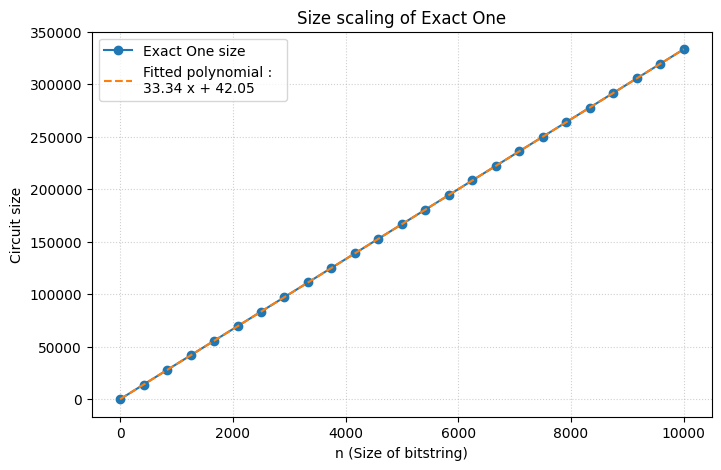

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(ns, sizes, marker="o", linestyle="-", label="Exact One size ")
plt.plot(ns, p(ns), marker="", linestyle="--", label=f"Fitted polynomial : {p}")
plt.xlabel("n (Size of bitstring)")
plt.ylabel("Circuit size")
plt.title("Size scaling of Exact One")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.show()

***Depth and Size Scaling of SPUE***

In [39]:
log_n_min=1
log_n_max=4
steps=25

raw_ns = np.logspace(log_n_min, log_n_max, steps)
ns = np.unique(np.round(raw_ns).astype(int))

depths = []
times = []

for n in ns:
    print(f"\nProcessing SPUE with n = {n}")
    t0 = time.time()

    qc = build_prepare_select_prepare_dag(n)
    qc = transpile(qc, basis_gates=['x','cx','ccx','u'])
    d = qc.depth()

    t = time.time() - t0
    print(f"  depth = {d} (took {t:.2f}s)")

    depths.append(d)
    times.append(t)

depths = np.array(depths, dtype=float)
times = np.array(times)


Processing SPUE with n = 10
  depth = 267 (took 0.02s)

Processing SPUE with n = 13
  depth = 315 (took 0.02s)

Processing SPUE with n = 18
  depth = 457 (took 0.03s)

Processing SPUE with n = 24
  depth = 505 (took 0.03s)

Processing SPUE with n = 32
  depth = 639 (took 0.04s)

Processing SPUE with n = 42
  depth = 639 (took 0.04s)

Processing SPUE with n = 56
  depth = 771 (took 0.06s)

Processing SPUE with n = 75
  depth = 797 (took 0.08s)

Processing SPUE with n = 100
  depth = 869 (took 0.10s)

Processing SPUE with n = 133
  depth = 955 (took 0.13s)

Processing SPUE with n = 178
  depth = 955 (took 0.17s)

Processing SPUE with n = 237
  depth = 1087 (took 0.24s)

Processing SPUE with n = 316
  depth = 1137 (took 0.31s)

Processing SPUE with n = 422
  depth = 1269 (took 0.42s)

Processing SPUE with n = 562
  depth = 1271 (took 0.57s)

Processing SPUE with n = 750
  depth = 1271 (took 0.76s)

Processing SPUE with n = 1000
  depth = 1427 (took 1.09s)

Processing SPUE with n = 1334
 

In [40]:
z = np.polyfit(np.log2(ns), depths, 1)
p = np.poly1d(z)

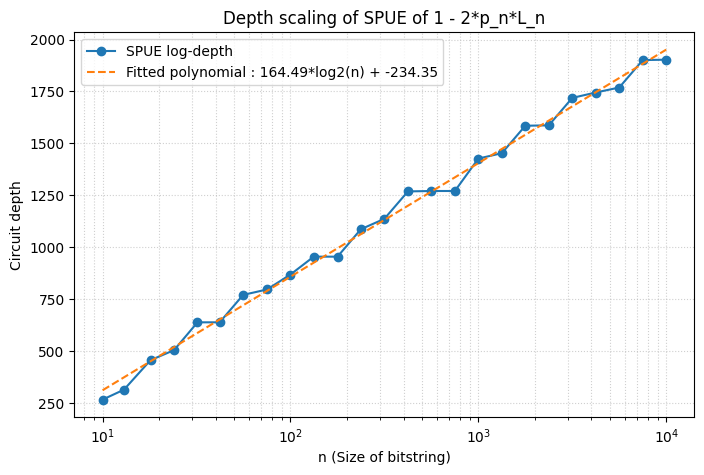

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(ns, depths, marker="o", linestyle="-", label="SPUE log-depth ")
plt.plot(ns, p(np.log2(ns)), marker="", linestyle="--", label=f"Fitted polynomial : {z[0]:.2f}*log2(n) + {z[1]:.2f}")
plt.xscale("log")
plt.xlabel("n (Size of bitstring)")
plt.ylabel("Circuit depth")
plt.title("Depth scaling of SPUE of 1 - 2*p_n*L_n")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.show()

In [42]:
n_min=2
n_max=10**4
steps=25

ns = np.unique(np.round(np.linspace(n_min, n_max, steps)).astype(int))

sizes = []
times = []

for n in ns:
    print(f"\nProcessing SPUE with n = {n}")
    t0 = time.time()

    qc = build_prepare_select_prepare_dag(n)
    qc = transpile(qc, basis_gates=['x','cx','ccx','u'])
    s = qc.size()

    t = time.time() - t0
    print(f"  size = {d} (took {t:.2f}s)")

    sizes.append(s)
    times.append(t)

sizes = np.array(sizes, dtype=float)
times = np.array(times)





Processing SPUE with n = 2
  size = 1903 (took 0.01s)

Processing SPUE with n = 419
  size = 1903 (took 0.35s)

Processing SPUE with n = 835
  size = 1903 (took 0.76s)

Processing SPUE with n = 1252
  size = 1903 (took 1.21s)

Processing SPUE with n = 1668
  size = 1903 (took 1.60s)

Processing SPUE with n = 2085
  size = 1903 (took 2.11s)

Processing SPUE with n = 2502
  size = 1903 (took 2.40s)

Processing SPUE with n = 2918
  size = 1903 (took 3.44s)

Processing SPUE with n = 3335
  size = 1903 (took 4.28s)

Processing SPUE with n = 3751
  size = 1903 (took 4.41s)

Processing SPUE with n = 4168
  size = 1903 (took 5.00s)

Processing SPUE with n = 4584
  size = 1903 (took 5.16s)

Processing SPUE with n = 5001
  size = 1903 (took 5.85s)

Processing SPUE with n = 5418
  size = 1903 (took 7.60s)

Processing SPUE with n = 5834
  size = 1903 (took 7.70s)

Processing SPUE with n = 6251
  size = 1903 (took 8.22s)

Processing SPUE with n = 6667
  size = 1903 (took 6.02s)

Processing SPUE wi

In [43]:
z = np.polyfit(ns, sizes, 1)
p = np.poly1d(z)

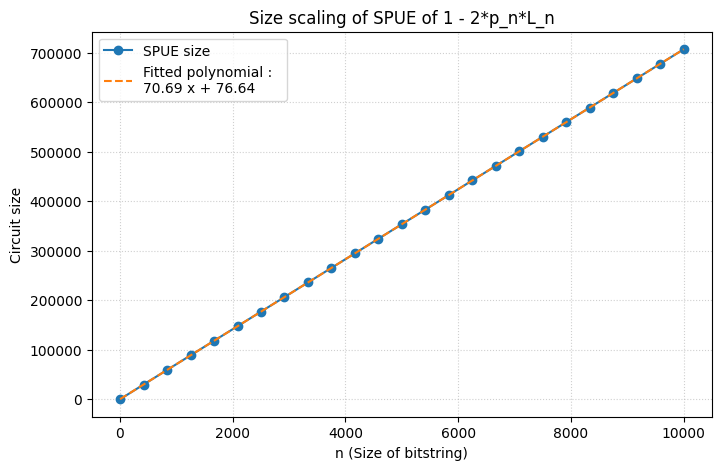

In [44]:
plt.figure(figsize=(8, 5))
plt.plot(ns, sizes, marker="o", linestyle="-", label="SPUE size ")
plt.plot(ns, p(ns), marker="", linestyle="--", label=f"Fitted polynomial : {p}")
plt.xlabel("n (Size of bitstring)")
plt.ylabel("Circuit size")
plt.title("Size scaling of SPUE of 1 - 2*p_n*L_n")
plt.grid(True, which="both", ls=":", alpha=0.6)
plt.legend()
plt.show()